### 1. ARIMA: qué significa y cómo funciona

ARIMA es uno de los enfoques más utilizados para la previsión de series temporales y se puede utilizar de dos maneras diferentes en función del tipo de datos de series temporales con los que se trabaje. En el primer caso, un modelo ARIMA no estacional que no requiere tener en cuenta la estacionalidad en sus datos de series temporales. Predecimos el futuro simplemente basándonos en patrones en los datos pasados. En el segundo caso, tenemos en cuenta la estacionalidad, que son los ciclos regulares que afectan a la serie temporal. Estos ciclos pueden ser diarios, semanales, mensuales, etc... y ayudan a definir patrones en los datos pasados de la serie temporal que se pueden utilizar para pronosticar valores futuros.

# 1.1 Significado de ARIMA(p, d, q)

ARIMA es un acrónimo de:

AR (p) = AutoRegresivo, es decir el presente depende de valores pasados
I(d) = Integral, quitamos tendencia (hacemos la serie estable)
MA (q) = Media Movil, el presente depende de errores pasados

# 1.2 Autoregresivo

En un modelo de autorregresión, pronosticamos la variable de interés utilizando una combinación lineal de valores pasados de la variable. El término autorregresión indica que se trata de una regresión de la variable contra sí misma. Esta técnica es similar a un modelo de regresión lineal en cuanto a que utiliza los valores del pasado como entradas para la regresión. La autorregresión se define como:

# 1.3 Media Movil

# 1.4 Integral

# 1.5 Autocorrelación




### Ejemplo código python:

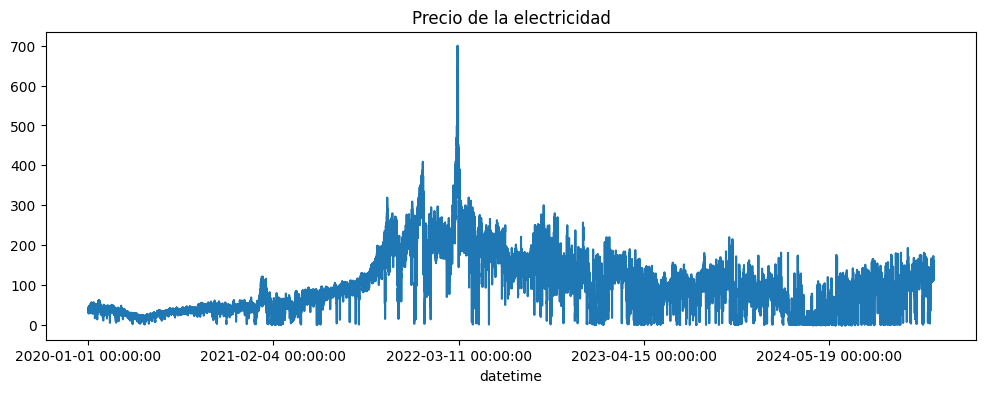

c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                45675
Model:                 ARIMA(1, 1, 1)   Log Likelihood             -167545.106
Date:                Tue, 24 Mar 2026   AIC                         335096.212
Time:                        10:13:43   BIC                         335122.400
Sample:                             0   HQIC                        335104.450
                              - 45675                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2736      0.006     44.592      0.000       0.262       0.286
ma.L1          0.1878      0.006     28.976      0.000       0.175       0.200
sigma2       115.9156      0.294    394.665      0.0

c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


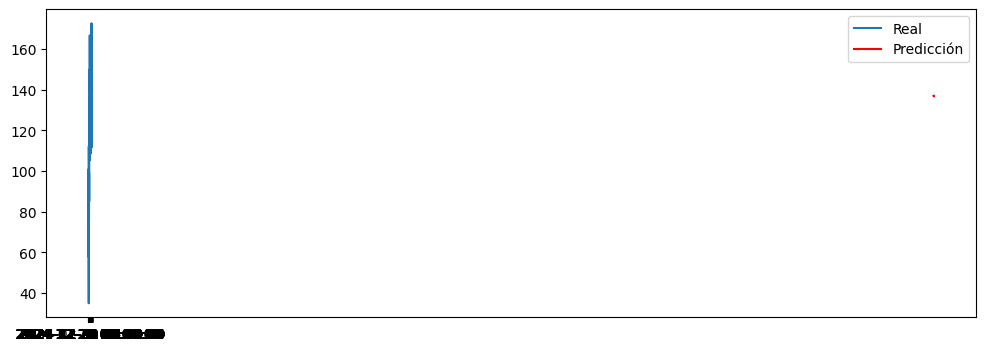

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


# Ejemplo: dataframe con columnas ['datetime', 'price']
df = pd.read_csv("limpiezaPrecio3_Omie2020_2024.csv", sep=";")

df = df.set_index("datetime")

# Visualizar, en las seires temp es importante
df["price"].plot(figsize=(12,4))
plt.title("Precio de la electricidad")
plt.show()

# Código báscico para ARIMA
model_arima = ARIMA(df["price"], order=(1,1,1))
result_arima = model_arima.fit()

print(result_arima.summary())

# Predecir próximas 24 horas
forecast = result_arima.forecast(steps=24)

plt.figure(figsize=(12,4))
plt.plot(df["price"][-200:], label="Real")
plt.plot(forecast, label="Predicción", color="red")
plt.legend()
plt.show()
